# TP 1 : Indicateurs Intraday et relations entre des variables journalières

Le but de ce TP est de se failiariser avec `pandas` et les bases de données et de construire les courbes intraday de certains indicateurs de marché tels que le volume, le nombre de trades, la volatilité, le spread, l'imbalance ou encore la liquidité disponible au meilleures limites (best bid et best ask). 

## I. Importation et lecture des données

Importer les librairies Python nécessaire.

In [1]:
import glob
import numpy as np
import pandas as pd
%matplotlib inline 
import matplotlib.pylab as plt
import datetime

Importation des données.

In [2]:
# Chemin vers les données
basedir = "C:/Users/Sophie/Documents/Notebooks/Cours Jussieu/Data/"
# Liste des chemins des fichiers de données
filenames = glob.glob(basedir + '*.h5')
# Liste des noms des actifs
stocknames = [file[55:-3] for file in filenames]
# Dictionnaire avec les dataframe de tous les actifs
df_trades = {stocknames[k] : pd.read_hdf(filenames[k]) for k in range(len(filenames))}

Afficher les premières lignes du dataframe AMAZON

In [3]:
df_trades["AMAZON"].head()

,TradedPrice,TradedQty,BidPrice,AskPrice,BidQty,AskQty,TradedSign
Time,,,,,,,
2011-01-03 09:30:00.188,181.32,100,181.25,181.35,100,200,0
2011-01-03 09:30:00.188,181.35,100,181.25,181.35,100,200,1
2011-01-03 09:30:00.201,181.35,100,181.25,181.35,100,100,1
2011-01-03 09:30:00.201,181.37,200,181.25,181.38,100,400,0
2011-01-03 09:30:00.201,181.38,100,181.25,181.38,100,400,1


## II. Graphiques des différents indicateurs intraday

### 1. Courbes de volume en % pour comparer les différents actifs

On va calculer la courbe de volume pour chaque jour, puis en faire la moyenne.

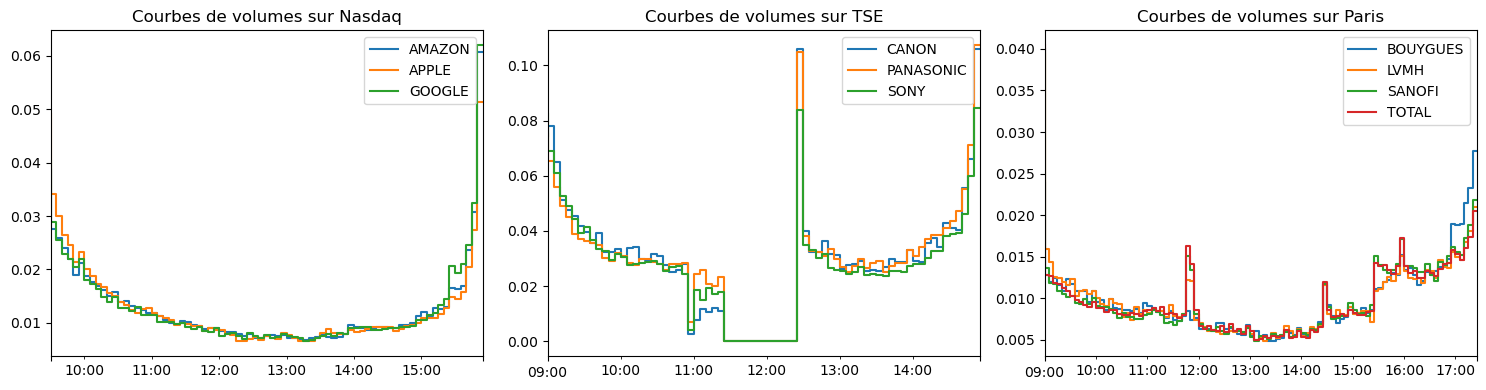

In [4]:
fig, axes = plt.subplots(1,3, figsize = (15,4))

for key in df_trades.keys():
    # Somme des volumes toutes les 5 minutes
    volume = df_trades[key]["TradedQty"].resample("5Min").sum().dropna()
    # On ne garde que les volumes >0
    volume = volume[volume>0]
    # Moyenne sur les jours de l'année
    Volume = volume.groupby([volume.index.hour,volume.index.minute]).mean()
    if key=="AMAZON" or key=="APPLE" or key=="GOOGLE":
        # numéro figure
        ax = 0
        # Nombre de bins de 5 minutes
        N = 78
        # Nom de la bourse
        market = "Nasdaq"
        # Vecteur de temps
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=30, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
            
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        ax = 1
        N = 72
        market = "TSE"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
        
    if key=="BOUYGUES" or key=="LVMH" or key=="SANOFI" or key=="TOTAL":
        ax = 2
        N = 102
        market = "Paris"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
    
    # Série temporelle de la courbe de volumes
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        s1 = Volume.values[:30]
        s2 = np.zeros(12)
        s3 = Volume.values[(len(Volume.values))-30:]
        CourbVolumes = pd.Series(np.concatenate((s1,s2,s3))/(np.sum(s1)+np.sum(s2)), index=indice)
    else:
        CourbVolumes = pd.Series(Volume.values[0:N]/Volume.values[0:N].sum(), index=indice)
    CourbVolumes.plot(drawstyle="steps", ax=axes[ax], label=key) 
    axes[ax].set_title("Courbes de volumes sur "+ market)
    axes[ax].legend()

plt.tight_layout()
plt.show()

### 2. Autres indicateurs à représenter

En plus des courbes de volumes précédentes (toujours par tranche de 5 minutes), il faut faire et commenter les graphiques suivants (enrenormalisant pour pouvoir comparer les différents actifs)


* Nombre de trades ;


* Turnover (cash) ;


* Spread moyen ; 


* Volatilité ;


* Imbalance : $|Q_{ask}-Q_{bid}|/(Q_{ask}+Q_{bid})$ ;


* Quantités aux best limits ($Q_{ask}+Q_{bid}$).

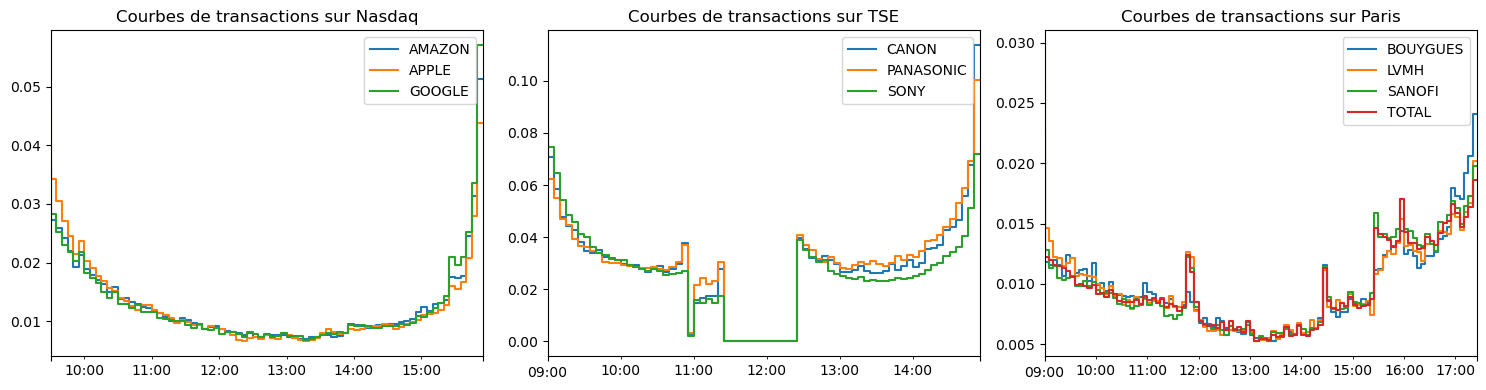

In [5]:
fig, axes = plt.subplots(1,3, figsize = (15,4))

for key in df_trades.keys():
    # Nombre de transactions toutes les 5 minutes
    trades = df_trades[key]["TradedQty"].resample("5Min").count().dropna()
    # On ne garde que les nombres >0
    trades = trades[trades>0]
    # Moyenne sur les jours de l'année
    Trades = trades.groupby([trades.index.hour,trades.index.minute]).mean()
    if key=="AMAZON" or key=="APPLE" or key=="GOOGLE":
        # numéro figure
        ax = 0
        # Nombre de bins de 5 minutes
        N = 78
        # Nom de la bourse
        market = "Nasdaq"
        # Vecteur de temps
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=30, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
            
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        ax = 1
        N = 72
        market = "TSE"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
        
    if key=="BOUYGUES" or key=="LVMH" or key=="SANOFI" or key=="TOTAL":
        ax = 2
        N = 102
        market = "Paris"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
    
    # Série temporelle de la courbe de volumes
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        s1 = Trades.values[:30]
        s2 = np.zeros(12)
        s3 = Trades.values[(len(Trades.values))-30:]
        CourbTrades = pd.Series(np.concatenate((s1,s2,s3))/(np.sum(s1)+np.sum(s2)), index=indice)
    else:
        CourbTrades = pd.Series(Trades.values[0:N]/Trades.values[0:N].sum(), index=indice)
    CourbTrades.plot(drawstyle="steps", ax=axes[ax], label=key)  
    axes[ax].set_title("Courbes de transactions sur "+ market)
    axes[ax].legend()

plt.tight_layout()
plt.show()

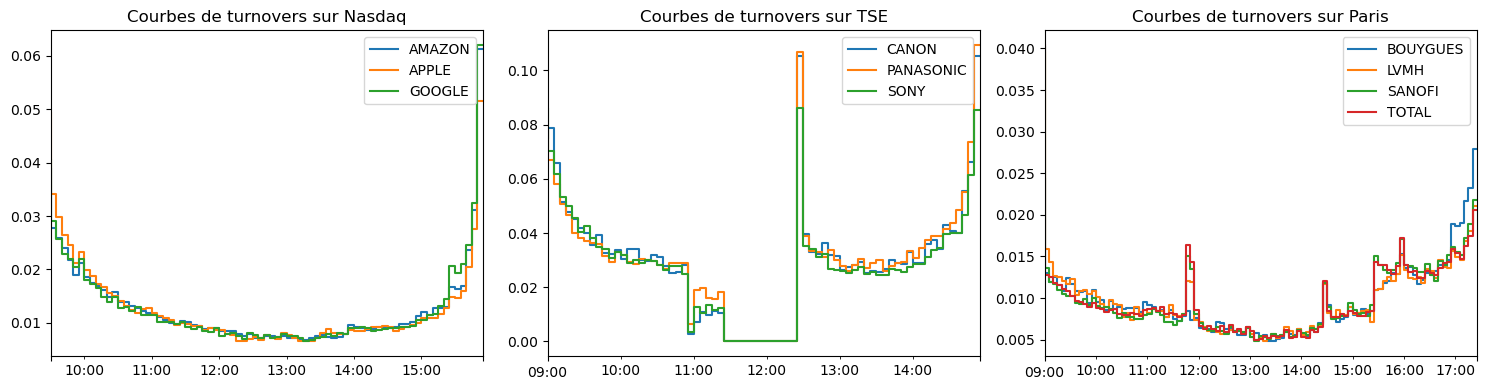

In [6]:
fig, axes = plt.subplots(1,3, figsize = (15,4))

for key in df_trades.keys():
    # Somme des montants des transactions toutes les 5 minutes
    turnover = (df_trades[key]["TradedQty"]*df_trades[key]["TradedPrice"]).resample("5Min").sum().dropna()
    # On ne garde que les montants >0
    turnover = turnover[turnover>0]
    # Moyenne sur les jours de l'année
    Turnover = turnover.groupby([turnover.index.hour,turnover.index.minute]).mean()
    if key=="AMAZON" or key=="APPLE" or key=="GOOGLE":
        # numéro figure
        ax = 0
        # Nombre de bins de 5 minutes
        N = 78
        # Nom de la bourse
        market = "Nasdaq"
        # Vecteur de temps
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=30, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
            
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        ax = 1
        N = 72
        market = "TSE"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
        
    if key=="BOUYGUES" or key=="LVMH" or key=="SANOFI" or key=="TOTAL":
        ax = 2
        N = 102
        market = "Paris"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
    
    # Série temporelle de la courbe de volumes
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        s1 = Turnover.values[:30]
        s2 = np.zeros(12)
        s3 = Turnover.values[(len(Turnover.values))-30:]
        CourbTurnover = pd.Series(np.concatenate((s1,s2,s3))/(np.sum(s1)+np.sum(s2)), index=indice)
    else:
        CourbTurnover = pd.Series(Turnover.values[0:N]/Turnover.values[0:N].sum(), index=indice)
    CourbTurnover.plot(drawstyle="steps", ax=axes[ax], label=key)  
    axes[ax].set_title("Courbes de turnovers sur "+ market)
    axes[ax].legend()

plt.tight_layout()
plt.show()

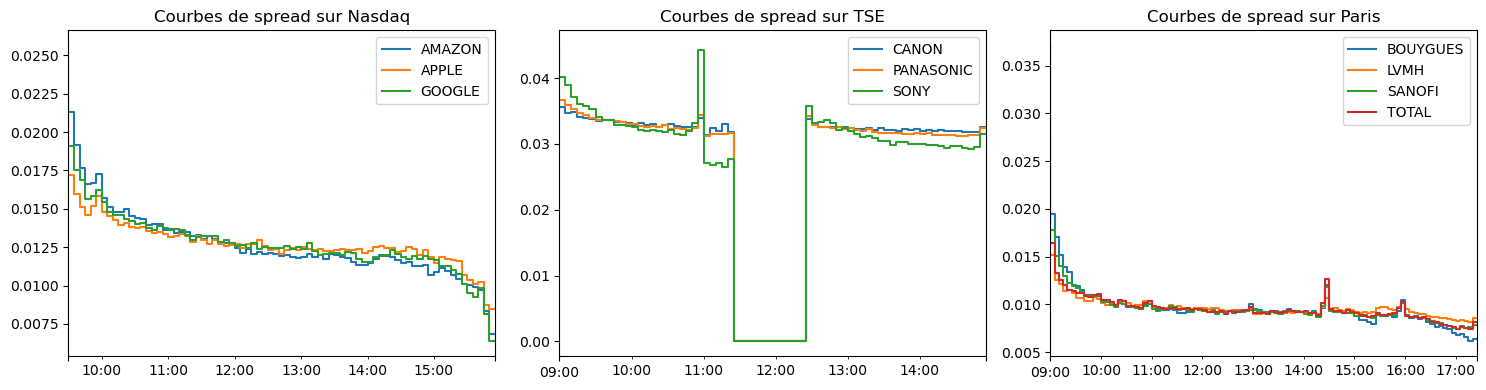

In [7]:
fig, axes = plt.subplots(1,3, figsize = (15,4))

for key in df_trades.keys():
    # Spread moyen toutes les 5 minutes
    spread = (df_trades[key]["AskPrice"]-df_trades[key]["BidPrice"]).resample("5Min").mean().dropna()
    # On ne garde que les spreads >0
    spread = spread[spread>0]
    # Moyenne sur les jours de l'année
    Spread = spread.groupby([spread.index.hour,spread.index.minute]).mean()
    if key=="AMAZON" or key=="APPLE" or key=="GOOGLE":
        # numéro figure
        ax = 0
        # Nombre de bins de 5 minutes
        N = 78
        # Nom de la bourse
        market = "Nasdaq"
        # Vecteur de temps
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=30, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
            
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        ax = 1
        N = 72
        market = "TSE"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
        
    if key=="BOUYGUES" or key=="LVMH" or key=="SANOFI" or key=="TOTAL":
        ax = 2
        N = 102
        market = "Paris"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
    
    # Série temporelle de la courbe de volumes
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        s1 = Spread.values[:30]
        s2 = np.zeros(12)
        s3 = Spread.values[(len(Spread.values))-30:]
        CourbSpread = pd.Series(np.concatenate((s1,s2,s3))/(np.sum(s1)+np.sum(s2)), index=indice)
    else:
        CourbSpread = pd.Series(Spread.values[0:N]/Spread.values[0:N].sum(), index=indice)
    CourbSpread.plot(drawstyle="steps", ax=axes[ax], label=key) 
    axes[ax].set_title("Courbes de spread sur "+ market)
    axes[ax].legend()

plt.tight_layout()
plt.show()

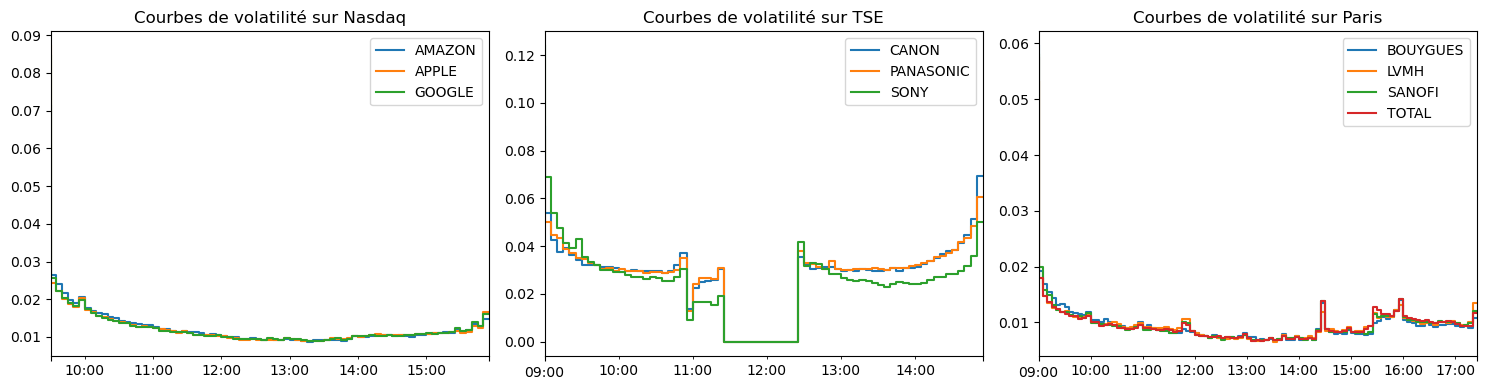

In [8]:
fig, axes = plt.subplots(1,3, figsize = (15,4))

for key in df_trades.keys():
    # Volatilité du prix des transactions toutes les 5 minutes
    vol = np.sqrt((df_trades[key]["TradedPrice"].diff().dropna()**2).resample("5Min").sum().dropna())
    # On ne garde que les vol >0
    vol = vol[vol>0]
    # Moyenne sur les jours de l'année
    Vol = vol.groupby([vol.index.hour,vol.index.minute]).mean()
    if key=="AMAZON" or key=="APPLE" or key=="GOOGLE":
        # numéro figure
        ax = 0
        # Nombre de bins de 5 minutes
        N = 78
        # Nom de la bourse
        market = "Nasdaq"
        # Vecteur de temps
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=30, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
            
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        ax = 1
        N = 72
        market = "TSE"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
        
    if key=="BOUYGUES" or key=="LVMH" or key=="SANOFI" or key=="TOTAL":
        ax = 2
        N = 102
        market = "Paris"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
    
    # Série temporelle de la courbe de volumes
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        s1 = Vol.values[:30]
        s2 = np.zeros(12)
        s3 = Vol.values[(len(Vol.values))-30:]
        CourbVol = pd.Series(np.concatenate((s1,s2,s3))/(np.sum(s1)+np.sum(s2)), index=indice)
    else:
        CourbVol = pd.Series(Vol.values[0:N]/Vol.values[0:N].sum(), index=indice)
    CourbVol.plot(drawstyle="steps", ax=axes[ax], label=key) 
    axes[ax].set_title("Courbes de volatilité sur "+ market)
    axes[ax].legend()

plt.tight_layout()
plt.show()

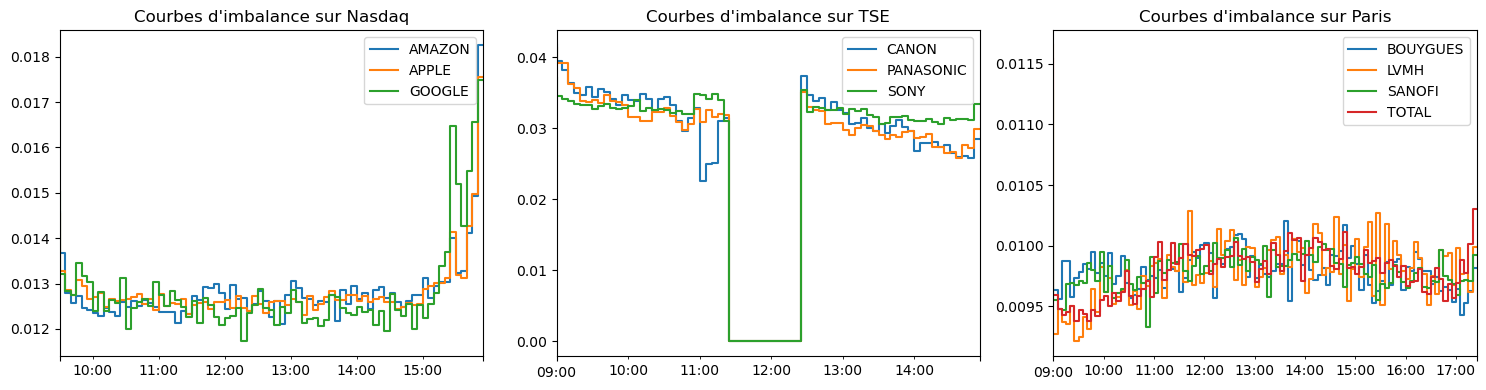

In [9]:
fig, axes = plt.subplots(1,3, figsize = (15,4))

for key in df_trades.keys():
    # Imbalance toutes les 5 minutes
    imb = (np.abs(df_trades[key]["AskQty"]-df_trades[key]["BidQty"])/(df_trades[key]["AskQty"]+df_trades[key]["BidQty"])).resample("5Min").mean().dropna()
    # On ne garde que les imbalances >0
    imb = imb[imb!=0]
    # Moyenne sur les jours de l'année
    Imb = imb.groupby([imb.index.hour,imb.index.minute]).mean()
    
    if key=="AMAZON" or key=="APPLE" or key=="GOOGLE":
        # numéro figure
        ax = 0
        # Nombre de bins de 5 minutes
        N = 78
        # Nom de la bourse
        market = "Nasdaq"
        # Vecteur de temps
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=30, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
            
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        ax = 1
        N = 72
        market = "TSE"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
        
    if key=="BOUYGUES" or key=="LVMH" or key=="SANOFI" or key=="TOTAL":
        ax = 2
        N = 102
        market = "Paris"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
    
    # Série temporelle de la courbe de volumes
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        s1 = Imb.values[:30]
        s2 = np.zeros(12)
        s3 = Imb.values[(len(Imb.values))-30:]
        CourbImb = pd.Series(np.concatenate((s1,s2,s3))/(np.sum(s1)+np.sum(s2)), index=indice)
    else:
        CourbImb = pd.Series(Imb.values[0:N]/Imb.values[0:N].sum(), index=indice)
    CourbImb.plot(drawstyle="steps", ax=axes[ax], label=key)  
    axes[ax].set_title("Courbes d'imbalance sur "+ market)
    axes[ax].legend()

plt.tight_layout()
plt.show()

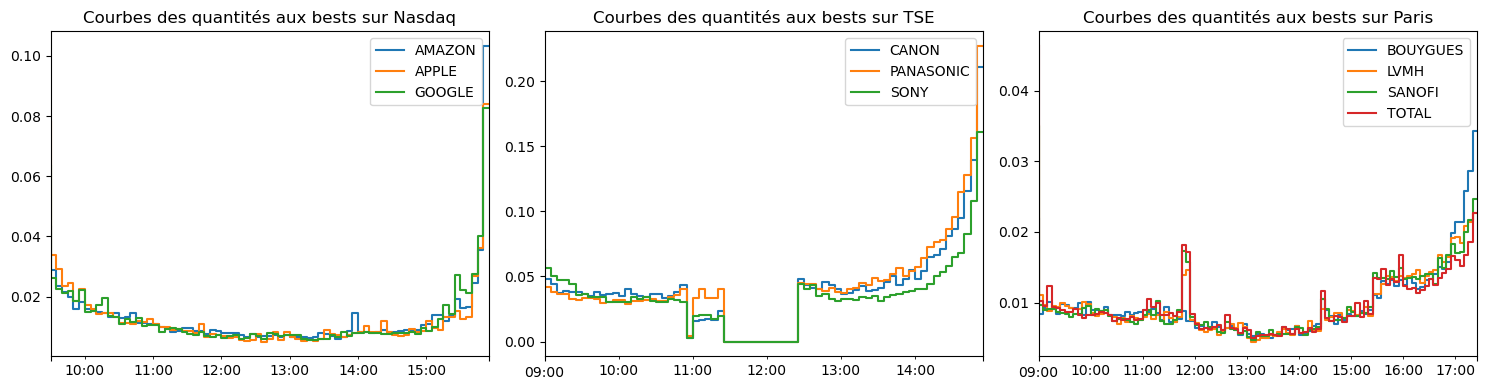

In [10]:
fig, axes = plt.subplots(1,3, figsize = (15,4))

for key in df_trades.keys():
    # quantités disponibles aux deux bests limits toutes les 5 minutes
    qty = (df_trades[key]["AskQty"]+df_trades[key]["BidQty"]).resample("5Min").sum().dropna()
    # On ne garde que les volumes >0
    qty = qty[qty>0]
    # Moyenne sur les jours de l'année
    Qty = qty.groupby([qty.index.hour,qty.index.minute]).mean()
    if key=="AMAZON" or key=="APPLE" or key=="GOOGLE":
        # numéro figure
        ax = 0
        # Nombre de bins de 5 minutes
        N = 78
        # Nom de la bourse
        market = "Nasdaq"
        # Vecteur de temps
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=30, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
            
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        ax = 1
        N = 72
        market = "TSE"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
        
    if key=="BOUYGUES" or key=="LVMH" or key=="SANOFI" or key=="TOTAL":
        ax = 2
        N = 102
        market = "Paris"
        ref = datetime.datetime.combine(datetime.date(year=2011, month=1, day=1), datetime.time(hour=9, minute=0, second=0)) 
        indice = [ref + i*datetime.timedelta(minutes=5) for i in range(N)]
    
    # Série temporelle de la courbe de volumes
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        s1 = Qty.values[:30]
        s2 = np.zeros(12)
        s3 = Qty.values[(len(Qty.values))-30:]
        CourbQty = pd.Series(np.concatenate((s1,s2,s3))/(np.sum(s1)+np.sum(s2)), index=indice)
    else:
        CourbQty = pd.Series(Qty.values[0:N]/Qty.values[0:N].sum(), index=indice)
    CourbQty.plot(drawstyle="steps", ax=axes[ax], label=key)         
    axes[ax].set_title("Courbes des quantités aux bests sur "+ market)
    axes[ax].legend()
    
plt.tight_layout()
plt.show()

## III. Relation entre les indicateurs journaliers

Vous allez regarder maintenant la relation entre certains indicateurs journaliers à l'aide de régression linéaire :
* relation entre les volumes et les nombres de trades, 
* entre les turnovers et les nombres de trades, 
pour l'ensemble des actifs et commenterez les résultats obtenus.

### 1. Relation Volumes/Nombre de transactions

In [11]:
# Module à importer pour la régression linéaire
import statsmodels.api as sm

Calculs des quantités journalières

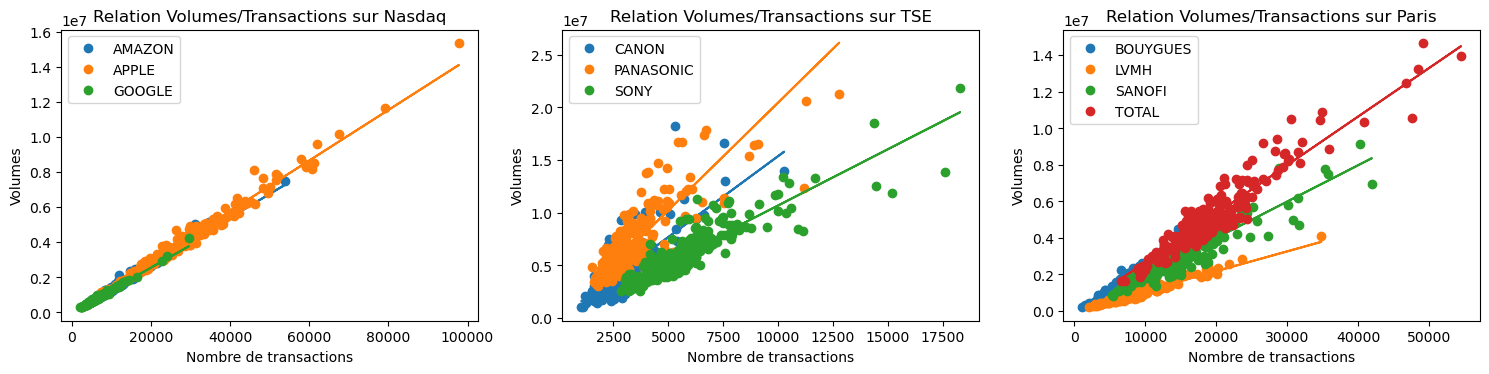

In [12]:
fig, axes = plt.subplots(1,3, figsize = (15,4))

for key in df_trades.keys():
    # Calcul volumes journaliers
    Volumes = df_trades[key]["TradedQty"].resample("D").sum()
    Volumes = Volumes[Volumes>0]
    # Calcule du nombre de transactions journalières
    Trades = df_trades[key]["TradedQty"].resample("D").count()
    Trades = Trades[Trades>0]
    
    # Régression linéaire des volumes sur le nombre de transaction
    model = sm.OLS(Volumes, Trades).fit() 
    
    if key=="AMAZON" or key=="APPLE" or key=="GOOGLE":
        # numéro figure
        ax = 0
        market = "Nasdaq"
            
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        ax = 1
        market = "TSE"
             
    if key=="BOUYGUES" or key=="LVMH" or key=="SANOFI" or key=="TOTAL":
        ax = 2
        market = "Paris"
        
    if key == "AMAZON" or key == "CANON" or key == "BOUYGUES":
        col = "C0"
    if key == "APPLE" or key == "PANASONIC" or key == "LVMH":
        col = "C1"
    if key == "GOOGLE" or key == "SONY" or key == "SANOFI":
        col = "C2"
    if key == "TOTAL":
        col = "C3"
           
    # Nuage de points
    axes[ax].plot(Trades, Volumes, 'o', color= col, label = key)
    # Ligne de régression
    axes[ax].plot(Trades, model.params.iloc[0]*Trades, color= col) 
    # Labels des axes
    axes[ax].set_xlabel("Nombre de transactions")
    axes[ax].set_ylabel("Volumes")
    axes[ax].set_title("Relation Volumes/Transactions sur "+ market)
    axes[ax].legend()

plt.tight_layout()
plt.show()

### 2. Realtion Turnovers/Nombre de transactions

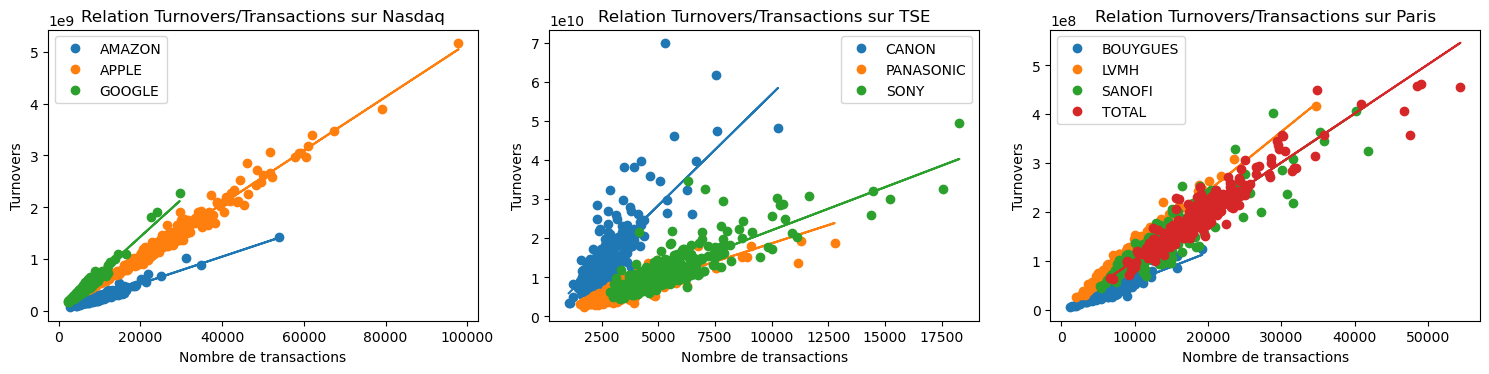

In [13]:
fig, axes = plt.subplots(1,3, figsize = (15,4))

for key in df_trades.keys():
    # Calcul turnovers journaliers
    Turnovers = (df_trades[key]["TradedQty"]*df_trades[key]["TradedPrice"]).resample("D").sum()
    Turnovers = Turnovers[Turnovers>0]
    # Calcule du nombre de transactions journalières
    Trades = df_trades[key]["TradedQty"].resample("D").count()
    Trades = Trades[Trades>0]
    # Régression linéaire des volumes sur le nombre de transaction
    model = sm.OLS(Turnovers, Trades).fit() 
    
    if key=="AMAZON" or key=="APPLE" or key=="GOOGLE":
        # numéro figure
        ax = 0
        market = "Nasdaq"
            
    if key=="CANON" or key=="PANASONIC" or key=="SONY":
        ax = 1
        market = "TSE"
             
    if key=="BOUYGUES" or key=="LVMH" or key=="SANOFI" or key=="TOTAL":
        ax = 2
        market = "Paris"
        
    if key == "AMAZON" or key == "CANON" or key == "BOUYGUES":
        col = "C0"
    if key == "APPLE" or key == "PANASONIC" or key == "LVMH":
        col = "C1"
    if key == "GOOGLE" or key == "SONY" or key == "SANOFI":
        col = "C2"
    if key == "TOTAL":
        col = "C3"
           
    # Nuage de points
    axes[ax].plot(Trades, Turnovers, 'o', color= col, label = key)
    # Ligne de régression
    axes[ax].plot(Trades, model.params.iloc[0]*Trades, color= col)    
    # Labels des axes
    axes[ax].set_xlabel("Nombre de transactions")
    axes[ax].set_ylabel("Turnovers")
    axes[ax].set_title("Relation Turnovers/Transactions sur "+ market)
    axes[ax].legend()

plt.tight_layout()
plt.show()